# 01 — Log Parsing

---

Parse 10,000 raw multi-format transaction log lines into a clean structured CSV.


## 1. Imports & Paths

In [1]:
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option('display.max_columns', 20)
pd.set_option('display.max_colwidth', 90)
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
COLORS = sns.color_palette('muted')

RAW_PATH       = Path('../data/raw/synthetic_dirty_transaction_logs.csv')
PROCESSED_PATH = Path('../data/processed/parsed_logs.csv')
PROCESSED_PATH.parent.mkdir(parents=True, exist_ok=True)

print('Paths set.')
print(f'  Raw data : {RAW_PATH}')
print(f'  Output   : {PROCESSED_PATH}')

Paths set.
  Raw data : ..\data\raw\synthetic_dirty_transaction_logs.csv
  Output   : ..\data\processed\parsed_logs.csv


## 2. Load Raw Data

In [2]:
raw_df = pd.read_csv(RAW_PATH)

print(f'Shape   : {raw_df.shape}')
print(f'Column  : {list(raw_df.columns)}')
print()
raw_df.head(10)

Shape   : (10000, 1)
Column  : ['raw_log']



,raw_log
0,2025-07-05 19:18:10::user1069::withdrawal::2995.12::London::iPhone 13
1,NaN
2,MALFORMED_LOG
3,usr:user1076|cashout|€4821.85|Glasgow|2025-07-15 12:56:05|Pixel 6
4,2025-07-20 05:38:14 >> [user1034] did top-up - amt=€2191.06 - None // dev:iPhone 13
5,2025-06-13 10:04:51 >> [user1068] did deposit - amt=€1691.09 - Glasgow // dev:None
6,2025-07-29 23:47:37 | user: user1014 | txn: deposit of £3539.5 from Glasgow | device: ...
7,MALFORMED_LOG
8,2025-06-23 14:45:58 - user=user1075 - action=debit $1215.74 - ATM: Leeds - device=Sams...
9,2025-07-31 06:50:50 | user: user1071 | txn: cashout of $1772.13 from None | device: No...


## 3. Inspect the Noise

Before parsing, i categorise every row into one of three buckets:

| Bucket | Description |
|---|---|
| **Null / empty** | Blank rows — no data at all |
| **MALFORMED_LOG** | Explicit bad-record marker from the source system |
| **Parseable** | A real log line in one of the 7 known formats |

In [3]:
total     = len(raw_df)
null_rows = raw_df['raw_log'].isna().sum()
malformed = (raw_df['raw_log'] == 'MALFORMED_LOG').sum()
parseable = total - null_rows - malformed

print('=' * 48)
print(f'  Total rows      : {total:>6,}')
print(f'  Null / empty    : {null_rows:>6,}  ({null_rows/total*100:.1f}%)')
print(f'  MALFORMED_LOG   : {malformed:>6,}  ({malformed/total*100:.1f}%)')
print(f'  Parseable       : {parseable:>6,}  ({parseable/total*100:.1f}%)')
print('=' * 48)

  Total rows      : 10,000
  Null / empty    :  1,124  (11.2%)
  MALFORMED_LOG   :  1,102  (11.0%)
  Parseable       :  7,774  (77.7%)


## 4. The 7 Log Formats

The raw data contains 7 distinct log schemas mixed together.  
Each encodes the same 6 fields in a different layout:
`timestamp`, `user_id`, `txn_type`, `amount`, `location`, `device`.

In [4]:
format_samples = {
    'pipe_colon'      : '2025-07-05 19:18:10::user1069::withdrawal::2995.12::London::iPhone 13',
    'arrow_bracket'   : '2025-07-20 05:38:14 >> [user1034] did top-up - amt=€2191.06 - None // dev:iPhone 13',
    'pipe_bar'        : '2025-07-31 06:50:50 | user: user1071 | txn: cashout of $1772.13 from None | device: Nokia 3310',
    'dash_equals'     : '2025-07-23 15:57:12 - user=user1098 - action=purchase €2019.47 - ATM: Glasgow - device=iPhone 13',
    'usr_pipe'        : 'usr:user1076|cashout|€4821.85|Glasgow|2025-07-15 12:56:05|Pixel 6',
    'space_separated' : 'user1093 2025-07-05 14:11:06 withdrawal 4926.56 None Huawei P30',
    'dmy_triple_colon': '24/07/2025 22:47:06 ::: user1080 *** PURCHASE ::: amt:951.85$ @ Liverpool <Xiaomi Mi 11>',
}

for fmt, sample in format_samples.items():
    print(f'[{fmt}]')
    print(f'  {sample}')
    print()

[pipe_colon]
  2025-07-05 19:18:10::user1069::withdrawal::2995.12::London::iPhone 13

[arrow_bracket]
  2025-07-20 05:38:14 >> [user1034] did top-up - amt=€2191.06 - None // dev:iPhone 13

[pipe_bar]
  2025-07-31 06:50:50 | user: user1071 | txn: cashout of $1772.13 from None | device: Nokia 3310

[dash_equals]
  2025-07-23 15:57:12 - user=user1098 - action=purchase €2019.47 - ATM: Glasgow - device=iPhone 13

[usr_pipe]
  usr:user1076|cashout|€4821.85|Glasgow|2025-07-15 12:56:05|Pixel 6

[space_separated]
  user1093 2025-07-05 14:11:06 withdrawal 4926.56 None Huawei P30

[dmy_triple_colon]
  24/07/2025 22:47:06 ::: user1080 *** PURCHASE ::: amt:951.85$ @ Liverpool <Xiaomi Mi 11>



## 5. Define Regex Patterns

One compiled regex per format.  
**Named groups** (`?P<field_name>`) are used throughout so field extraction  
is always by name — not by position — regardless of format.

In [5]:
PATTERNS = {

    # 2025-07-05 19:18:10::user1069::withdrawal::2995.12::London::iPhone 13
    'pipe_colon': re.compile(
        r'(?P<timestamp>\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2})'
        r'::(?P<user_id>user\d+)'
        r'::(?P<txn_type>\w[\w-]*)'
        r'::(?P<amount>[\d.]+)'
        r'::(?P<location>[^:]+)'
        r'::(?P<device>.+)'
    ),

    # 2025-07-20 05:38:14 >> [user1034] did top-up - amt=€2191.06 - None // dev:iPhone 13
    'arrow_bracket': re.compile(
        r'(?P<timestamp>\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2})'
        r'\s*>>\s*\[(?P<user_id>user\d+)\]\s*did\s+(?P<txn_type>[\w-]+)'
        r'\s*-\s*amt=(?P<currency>[€£\$])(?P<amount>[\d.]+)'
        r'\s*-\s*(?P<location>\S+)\s*//\s*dev:(?P<device>.+)'
    ),

    # 2025-07-31 06:50:50 | user: user1071 | txn: cashout of $1772.13 from None | device: Nokia 3310
    'pipe_bar': re.compile(
        r'(?P<timestamp>\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2})'
        r'\s*\|\s*user:\s*(?P<user_id>user\d+)'
        r'\s*\|\s*txn:\s*(?P<txn_type>[\w-]+)\s+of\s+(?P<currency>[€£\$])(?P<amount>[\d.]+)'
        r'\s+from\s+(?P<location>\S+)'
        r'\s*\|\s*device:\s*(?P<device>.+)'
    ),

    # 2025-07-23 15:57:12 - user=user1098 - action=purchase €2019.47 - ATM: Glasgow - device=iPhone 13
    'dash_equals': re.compile(
        r'(?P<timestamp>\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2})'
        r'\s*-\s*user=(?P<user_id>user\d+)'
        r'\s*-\s*action=(?P<txn_type>[\w-]+)\s+(?P<currency>[€£\$])(?P<amount>[\d.]+)'
        r'\s*-\s*ATM:\s*(?P<location>\S+)'
        r'\s*-\s*device=(?P<device>.+)'
    ),

    # usr:user1076|cashout|€4821.85|Glasgow|2025-07-15 12:56:05|Pixel 6
    'usr_pipe': re.compile(
        r'usr:(?P<user_id>user\d+)'
        r'\|(?P<txn_type>[\w-]+)'
        r'\|(?P<currency>[€£\$])(?P<amount>[\d.]+)'
        r'\|(?P<location>[^|]+)'
        r'\|(?P<timestamp>\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2})'
        r'\|(?P<device>.+)'
    ),

    # user1093 2025-07-05 14:11:06 withdrawal 4926.56 None Huawei P30
    'space_separated': re.compile(
        r'(?P<user_id>user\d+)\s+'
        r'(?P<timestamp>\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2})\s+'
        r'(?P<txn_type>[\w-]+)\s+'
        r'(?P<amount>[\d.]+)\s+'
        r'(?P<location>\S+)\s+'
        r'(?P<device>.+)'
    ),

    # 24/07/2025 22:47:06 ::: user1080 *** PURCHASE ::: amt:951.85$ @ Liverpool <Xiaomi Mi 11>
    'dmy_triple_colon': re.compile(
        r'(?P<day>\d{2})/(?P<month>\d{2})/(?P<year>\d{4})\s+(?P<time>\d{2}:\d{2}:\d{2})'
        r'\s+:::\s+(?P<user_id>user\d+)'
        r'\s+\*\*\*\s+(?P<txn_type>[A-Z\-]+)'
        r'\s+:::\s+amt:(?P<amount>[\d.]+)(?P<currency>[€£\$])'
        r'\s+@\s+(?P<location>\S+)'
        r'\s+<(?P<device>[^>]+)>'
    ),
}

# Missing-value placeholders — any of these become NaN
NONE_PLACEHOLDERS = {'none', 'null', 'n/a', 'na', '-', ''}

print(f'{len(PATTERNS)} patterns compiled.')

7 patterns compiled.


## 6. Helper Functions

Two small helpers before the main parse function:

- `_normalise_timestamp` — reassembles split date parts for `dmy_triple_colon`
- `_clean_field` — converts known missing-value strings (`'None'`, `'null'`, etc.) to `NaN`

In [6]:
def _normalise_timestamp(match, fmt_name):
    """
    Six formats store the timestamp as a single captured group.
    dmy_triple_colon splits it into day / month / year / time — we reassemble.
    """
    if fmt_name == 'dmy_triple_colon':
        return (
            f"{match.group('year')}-{match.group('month')}-{match.group('day')}"
            f" {match.group('time')}"
        )
    return match.group('timestamp')


def _clean_field(value):
    """Strip whitespace; return None for any known missing-value placeholder."""
    if value is None:
        return None
    stripped = value.strip()
    if stripped.lower() in NONE_PLACEHOLDERS:
        return None
    return stripped


print('Helper functions defined.')

Helper functions defined.


## 7. Parse Function

`parse_log_line` takes one raw string and tries each pattern in order.  
It returns a dict of fields on success, or `None` if the line cannot be parsed.  

**Guard conditions (return None immediately):**
- Row is `NaN`
- Row is the literal string `MALFORMED_LOG`
- Row is blank

**For matched lines:**
- Amount must be a valid float — otherwise skip
- Timestamp is normalised to `YYYY-MM-DD HH:MM:SS`
- All fields pass through `_clean_field` so `'None'` strings become proper `NaN`

In [7]:
def parse_log_line(raw):
    # Guard: drop nulls, MALFORMED_LOG, empty strings
    if pd.isna(raw):
        return None
    raw = str(raw).strip()
    if raw.upper() == 'MALFORMED_LOG' or raw == '':
        return None

    for fmt_name, pattern in PATTERNS.items():
        m = pattern.search(raw)
        if not m:
            continue  # try next pattern

        gd = m.groupdict()

        # Amount must be a valid float
        try:
            amount = float(gd.get('amount', ''))
        except (ValueError, TypeError):
            continue

        return {
            'timestamp'  : _normalise_timestamp(m, fmt_name),
            'user_id'    : _clean_field(gd.get('user_id')),
            'txn_type'   : _clean_field(gd.get('txn_type', '').lower()),
            'amount'     : amount,
            'currency'   : _clean_field(gd.get('currency')),
            'location'   : _clean_field(gd.get('location')),
            'device'     : _clean_field(gd.get('device')),
            'log_format' : fmt_name,
        }

    return None  # no pattern matched


print('parse_log_line() defined.')

parse_log_line() defined.


## 8. Smoke Test — One Line Per Format

Before running on 10,000 rows, verify the parser handles each format correctly.

In [8]:
test_lines = [
    ('pipe_colon',       '2025-07-05 19:18:10::user1069::withdrawal::2995.12::London::iPhone 13'),
    ('arrow_bracket',    '2025-07-20 05:38:14 >> [user1034] did top-up - amt=€2191.06 - None // dev:iPhone 13'),
    ('pipe_bar',         '2025-07-31 06:50:50 | user: user1071 | txn: cashout of $1772.13 from None | device: Nokia 3310'),
    ('dash_equals',      '2025-07-23 15:57:12 - user=user1098 - action=purchase €2019.47 - ATM: Glasgow - device=iPhone 13'),
    ('usr_pipe',         'usr:user1076|cashout|€4821.85|Glasgow|2025-07-15 12:56:05|Pixel 6'),
    ('space_separated',  'user1093 2025-07-05 14:11:06 withdrawal 4926.56 None Huawei P30'),
    ('dmy_triple_colon', '24/07/2025 22:47:06 ::: user1080 *** PURCHASE ::: amt:951.85$ @ Liverpool <Xiaomi Mi 11>'),
    ('null_row',         None),
    ('malformed',        'MALFORMED_LOG'),
]

print('{:<20} {}'.format('Format', 'Result'))
print('-' * 60)
for fmt, line in test_lines:
    result = parse_log_line(line)
    if result is None:
        print('{:<20} None (correctly dropped)'.format(fmt))
    else:
        print('{:<20} OK | user={} | {} | {} | {}'.format(
            fmt, result['user_id'], result['txn_type'],
            result['amount'], result['location']
        ))

Format               Result
------------------------------------------------------------
pipe_colon           OK | user=user1069 | withdrawal | 2995.12 | London
arrow_bracket        OK | user=user1034 | top-up | 2191.06 | None
pipe_bar             OK | user=user1071 | cashout | 1772.13 | None
dash_equals          OK | user=user1098 | purchase | 2019.47 | Glasgow
usr_pipe             OK | user=user1076 | cashout | 4821.85 | Glasgow
space_separated      OK | user=user1093 | withdrawal | 4926.56 | None
dmy_triple_colon     OK | user=user1080 | purchase | 951.85 | Liverpool
null_row             None (correctly dropped)
malformed            None (correctly dropped)


## 9. Parse the Full Dataset

Apply `parse_log_line` to all 10,000 rows.  
Collect results, drop `None` rows, convert timestamp to datetime.

In [9]:
print('Parsing 10,000 rows...')

records = [parse_log_line(row) for row in raw_df['raw_log']]
records = [r for r in records if r is not None]

parsed_df = pd.DataFrame(records)
parsed_df['timestamp'] = pd.to_datetime(parsed_df['timestamp'], errors='coerce')

dropped = len(raw_df) - len(parsed_df)

print(f'Done.')
print(f'  Input rows  : {len(raw_df):,}')
print(f'  Parsed rows : {len(parsed_df):,}')
print(f'  Dropped     : {dropped:,}  ({dropped/len(raw_df)*100:.1f}% noise)')
print()
parsed_df.head()

Parsing 10,000 rows...
Done.
  Input rows  : 10,000
  Parsed rows : 7,774
  Dropped     : 2,226  (22.3% noise)



,timestamp,user_id,txn_type,amount,currency,location,device,log_format
0,2025-07-05 19:18:10,user1069,withdrawal,2995.12,None,London,iPhone 13,pipe_colon
1,2025-07-15 12:56:05,user1076,cashout,4821.85,€,Glasgow,Pixel 6,usr_pipe
2,2025-07-20 05:38:14,user1034,top-up,2191.06,€,None,iPhone 13,arrow_bracket
3,2025-06-13 10:04:51,user1068,deposit,1691.09,€,Glasgow,None,arrow_bracket
4,2025-07-29 23:47:37,user1014,deposit,3539.50,£,Glasgow,iPhone 13,pipe_bar


## 10. Validate — Format Distribution

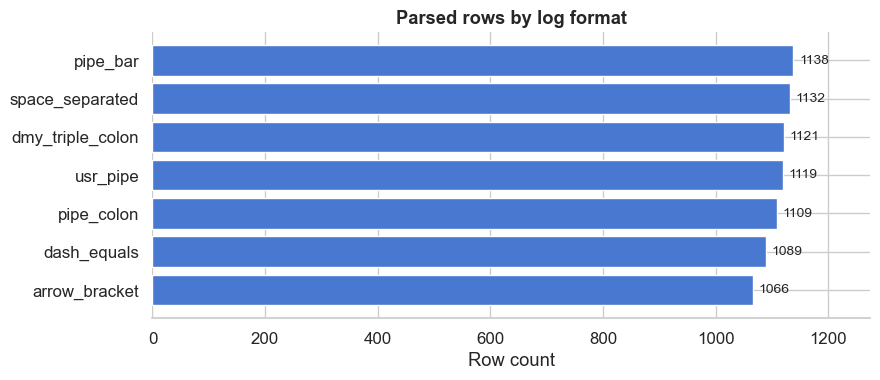

arrow_bracket       1066
dash_equals         1089
pipe_colon          1109
usr_pipe            1119
dmy_triple_colon    1121
space_separated     1132
pipe_bar            1138


In [10]:
fmt_counts = parsed_df['log_format'].value_counts().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(fmt_counts.index, fmt_counts.values, color=COLORS[0], edgecolor='white')
ax.bar_label(bars, padding=4, fontsize=10)
ax.set_xlabel('Row count')
ax.set_title('Parsed rows by log format', fontweight='bold')
ax.set_xlim(0, fmt_counts.max() * 1.12)
sns.despine(left=True)
plt.tight_layout()
plt.show()

print(fmt_counts.to_string())

## 11. Validate — Missing Values

- `currency` — missing for formats that don't include a symbol (`pipe_colon`, `space_separated`)
- `location` / `device` — missing where the source log had `None` as a placeholder

            null_count  null_%
timestamp            0     0.0
user_id              0     0.0
txn_type             0     0.0
amount               0     0.0
currency          2241    28.8
location           968    12.5
device            1081    13.9
log_format           0     0.0


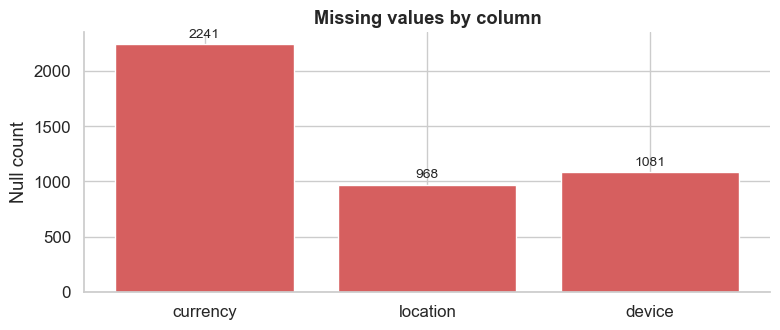

In [11]:
nulls     = parsed_df.isnull().sum().rename('null_count')
nulls_pct = (nulls / len(parsed_df) * 100).round(1).rename('null_%')
print(pd.concat([nulls, nulls_pct], axis=1).to_string())

fig, ax = plt.subplots(figsize=(8, 3.5))
cols_with_nulls = nulls[nulls > 0]
bars = ax.bar(cols_with_nulls.index, cols_with_nulls.values, color=COLORS[3], edgecolor='white')
ax.bar_label(bars, padding=3, fontsize=10)
ax.set_ylabel('Null count')
ax.set_title('Missing values by column', fontweight='bold')
sns.despine()
plt.tight_layout()
plt.show()

## 12. Validate — Transaction Types

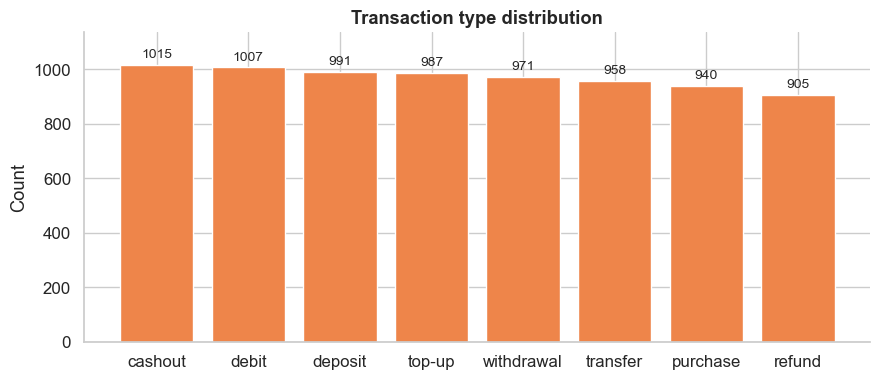

In [12]:
txn_counts = parsed_df['txn_type'].value_counts()

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(txn_counts.index, txn_counts.values, color=COLORS[1], edgecolor='white')
ax.bar_label(bars, padding=3, fontsize=10)
ax.set_ylabel('Count')
ax.set_title('Transaction type distribution', fontweight='bold')
ax.set_ylim(0, txn_counts.max() * 1.12)
sns.despine()
plt.tight_layout()
plt.show()

## 13. Validate — Amount Distribution

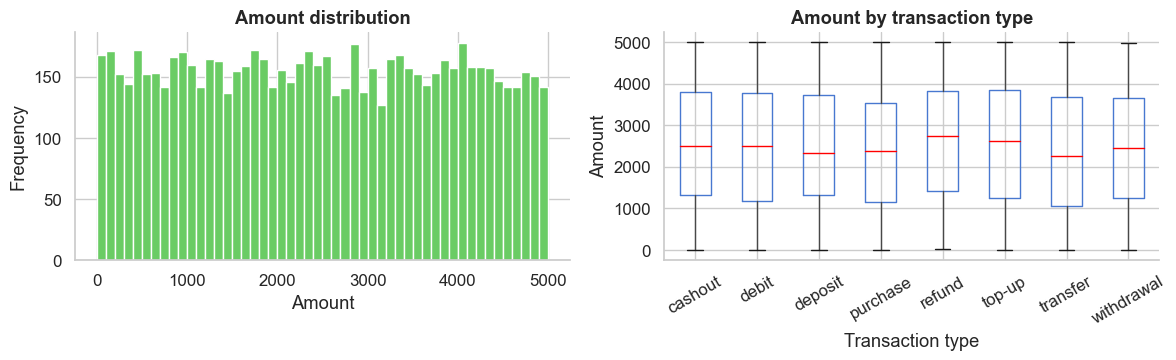

count    7774.00
mean     2479.18
std      1441.02
min         1.62
25%      1231.76
50%      2464.39
75%      3741.26
max      4998.25


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(parsed_df['amount'], bins=50, color=COLORS[2], edgecolor='white')
axes[0].set_xlabel('Amount')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Amount distribution', fontweight='bold')

parsed_df.boxplot(column='amount', by='txn_type', ax=axes[1],
                  boxprops=dict(color=COLORS[0]),
                  medianprops=dict(color='red'))
axes[1].set_title('Amount by transaction type', fontweight='bold')
axes[1].set_xlabel('Transaction type')
axes[1].set_ylabel('Amount')
plt.suptitle('')
plt.xticks(rotation=30)
sns.despine()
plt.tight_layout()
plt.show()

print(parsed_df['amount'].describe().round(2).to_string())

## 14. Validate — User Activity

Unique users       : 65
Min txns / user    : 29
Max txns / user    : 238
Mean txns / user   : 90.4


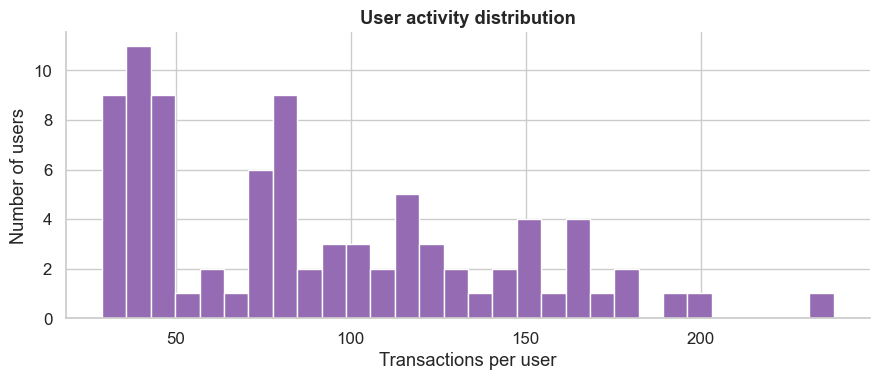

In [14]:
user_txn_counts = parsed_df['user_id'].value_counts()

print(f'Unique users       : {user_txn_counts.nunique():,}')
print(f'Min txns / user    : {user_txn_counts.min()}')
print(f'Max txns / user    : {user_txn_counts.max()}')
print(f'Mean txns / user   : {user_txn_counts.mean():.1f}')

fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(user_txn_counts.values, bins=30, color=COLORS[4], edgecolor='white')
ax.set_xlabel('Transactions per user')
ax.set_ylabel('Number of users')
ax.set_title('User activity distribution', fontweight='bold')
sns.despine()
plt.tight_layout()
plt.show()

## 15. Validate — Date Range & Daily Volume

Earliest : 2025-06-01 11:41:41
Latest   : 2025-07-31 11:14:57
Span     : 59 days


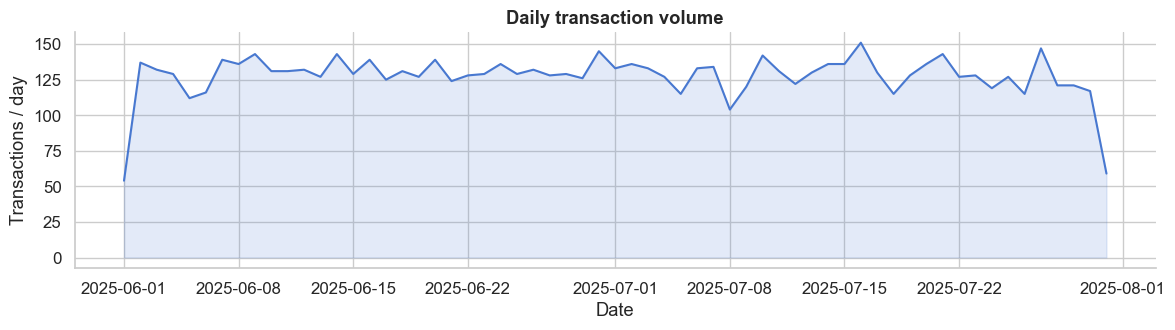

In [15]:
print(f'Earliest : {parsed_df["timestamp"].min()}')
print(f'Latest   : {parsed_df["timestamp"].max()}')
print(f'Span     : {(parsed_df["timestamp"].max() - parsed_df["timestamp"].min()).days} days')

daily = parsed_df.set_index('timestamp').resample('D').size()

fig, ax = plt.subplots(figsize=(12, 3.5))
ax.plot(daily.index, daily.values, color=COLORS[0], linewidth=1.5)
ax.fill_between(daily.index, daily.values, alpha=0.15, color=COLORS[0])
ax.set_xlabel('Date')
ax.set_ylabel('Transactions / day')
ax.set_title('Daily transaction volume', fontweight='bold')
sns.despine()
plt.tight_layout()
plt.show()

## 16. Parsing Summary

In [16]:
summary = {
    'Raw rows'           : len(raw_df),
    'Null / empty rows'  : int(null_rows),
    'MALFORMED_LOG rows' : int(malformed),
    'Parsed rows'        : len(parsed_df),
    'Parse success rate' : f'{len(parsed_df)/len(raw_df)*100:.1f}%',
    'Unique users'       : parsed_df['user_id'].nunique(),
    'Unique txn types'   : parsed_df['txn_type'].nunique(),
    'Date range'         : f'{parsed_df["timestamp"].min().date()} to {parsed_df["timestamp"].max().date()}',
    'Amount range'       : f'{parsed_df["amount"].min():.2f} to {parsed_df["amount"].max():.2f}',
    'Log formats found'  : parsed_df['log_format'].nunique(),
}

print('=' * 50)
print('  PARSING SUMMARY')
print('=' * 50)
for k, v in summary.items():
    print(f'  {k:<25}: {v}')
print('=' * 50)

  PARSING SUMMARY
  Raw rows                 : 10000
  Null / empty rows        : 1124
  MALFORMED_LOG rows       : 1102
  Parsed rows              : 7774
  Parse success rate       : 77.7%
  Unique users             : 86
  Unique txn types         : 8
  Date range               : 2025-06-01 to 2025-07-31
  Amount range             : 1.62 to 4998.25
  Log formats found        : 7


## 17. Save to Processed Folder

This CSV is the single input for every notebook that follows.

In [17]:
parsed_df.to_csv(PROCESSED_PATH, index=False)

# Verify the saved file
verify = pd.read_csv(PROCESSED_PATH)

print(f'Saved   : {PROCESSED_PATH}')
print(f'Size    : {PROCESSED_PATH.stat().st_size / 1024:.1f} KB')
print(f'Shape   : {verify.shape}')
print(f'Columns : {list(verify.columns)}')

Saved   : ..\data\processed\parsed_logs.csv
Size    : 599.9 KB
Shape   : (7774, 8)
Columns : ['timestamp', 'user_id', 'txn_type', 'amount', 'currency', 'location', 'device', 'log_format']
